[*********************100%***********************]  6 of 6 completed


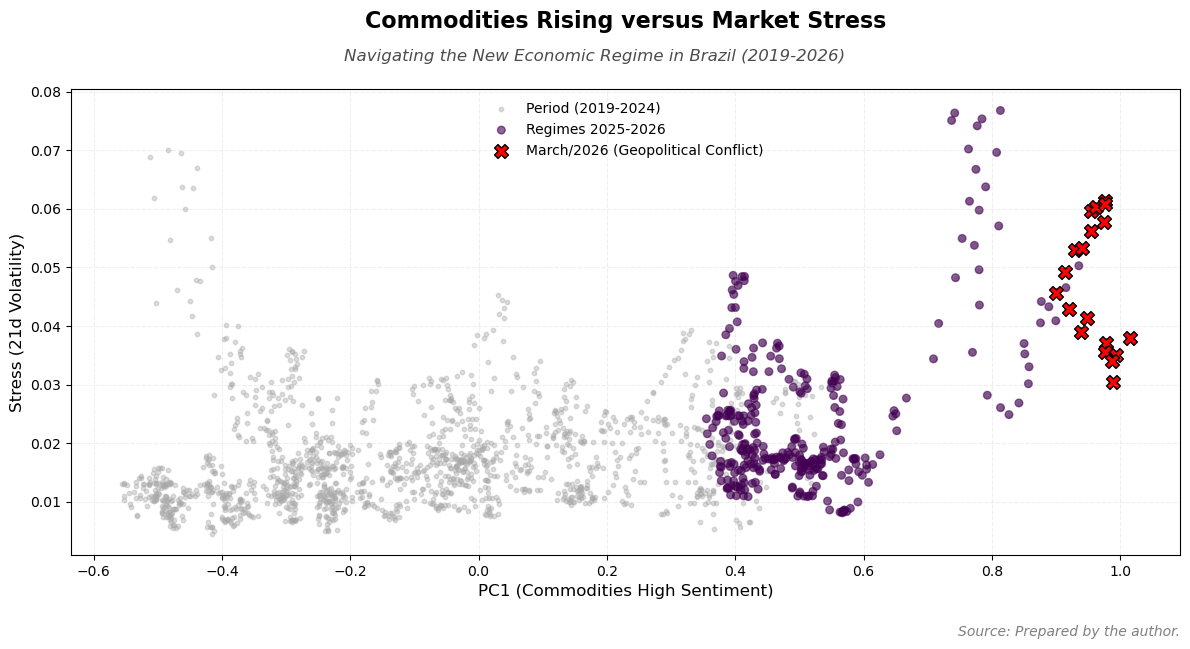

PC1 DNA - Loadings (Sorted by Sentiment):
       PC1 (Sentiment)  PC2 (Risk/Vol)
Dolar         0.622343        0.096246
DXY           0.496964       -0.347465
Petro         0.357632       -0.185872
Ibov          0.357606       -0.298764
Gold          0.287076        0.726713
Brent         0.165893        0.466996


In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

np.random.seed(42)

# 1. Data Collection
tickers = {
    "Brent": "BZ=F", 
    "Gold": "GC=F", 
    "DXY": "DX-Y.NYB", 
    "Dolar": "USDBRL=X", 
    "Ibov": "^BVSP", 
    "Petro": "PETR4.SA"
}

data = yf.download(list(tickers.values()), start="2019-01-01", auto_adjust=True)['Close']
df = data.rename(columns={v: k for k, v in tickers.items()}).ffill().dropna()

# 2. PCA - Dimensionality Reduction
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df)
pca = PCA(n_components=2)
pca_results = pca.fit_transform(df_scaled)
df['PC1'] = pca_results[:,0]
df['PC2'] = pca_results[:,1]

# 3. Defining Stress and Commodities Regimes
# Stress = moving standard deviation (21-day window)
df['Stress'] = df['PC1'].rolling(window=21).std()
df = df.dropna()

# 4. Clustering - Regime Identification
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df[['PC1', 'PC2']])

# 5. Data Visualization (Scatter Plot)
plt.figure(figsize=(12, 7))

# Historical Context (2019-2024)
plt.scatter(df['PC1'], df['Stress'], c='darkgray', alpha=0.4, s=10, label='Period (2019-2024)')

# New Normal / Resilience Period (2025-2026)
df_recent = df[df.index >= '2025-01-01']
plt.scatter(df_recent['PC1'], df_recent['Stress'], c=df_recent['Cluster'], cmap='viridis', s=30, alpha=0.6, label='Regimes 2025-2026')

# Geopolitical Conflict Highlight (March 2026)
df_conflict = df[df.index >= '2026-03-10']
plt.scatter(df_conflict['PC1'], df_conflict['Stress'], color='red', edgecolors='black', s=100, marker='X', label='March/2026 (Geopolitical Conflict)')

# Chart 
plt.title('Commodities Rising versus Market Stress\n', fontsize=16, fontweight = 'bold', pad=25)
plt.suptitle('Navigating the New Economic Regime in Brazil (2019-2026)', fontsize = 12, y = 0.88, style = 'italic', alpha = .7)
plt.xlabel('PC1 (Commodities High Sentiment)', fontsize=12)
plt.ylabel('Stress (21d Volatility)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.2)
plt.text(1.0, -0.15, 'Source: Prepared by the author.', transform=plt.gca().transAxes, 
         fontsize=10, color='gray', ha='right', va='top', style='italic')
plt.legend(loc='upper center', fontsize=10, frameon=False)
plt.tight_layout()
plt.savefig('scatter_commodities_market_final.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. PCA Loadings
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1 (Sentiment)', 'PC2 (Risk/Vol)'], 
    index=list(tickers.keys())
)

# Sorting and displaying loadings
print("PC1 DNA - Loadings (Sorted by Sentiment):")
sorted_loadings = loadings.sort_values(by='PC1 (Sentiment)', ascending=False)
print(sorted_loadings)

# 7. Exporting to Excel
loadings.to_excel('loadings_analysis.xlsx')